# Steam Review Sentiment & Network Analysis
**Research Question:** How does Steam review sentiment vary between genres, and do users review games only within a single genre or across multiple genres?

**Genres:** Horror | RPG | Strategy  

---
## 0 – Imports

In [1]:
import pandas as pd
import numpy as np
import re
import os
import json
from itertools import combinations
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import networkx as nx
from networkx.algorithms import bipartite
from networkx.algorithms.community import greedy_modularity_communities

nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords',    quiet=True)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

STOP = set(stopwords.words('english'))
sentAnalyser = SentimentIntensityAnalyzer()

print('All imports OK')

All imports OK


---
## 1 – Load Data

Reads every `review_<appid>.json` from the `data/` folder.  
> **Note:** App ID `489830` is Skyrim Special Edition (substituted for Baldur's Gate 3 which uses a different ID). Update `appid_dict` here if you swap any game.

In [2]:
appid_dict = {
    # ── Horror ───────────────────────────────────────────────────────────────
    '1622910' : ['Still Wakes the Deep',                   'Horror'],
    '1196590' : ['Resident Evil Village',                  'Horror'],
    '3180070' : ['No Im Not a Human',                      'Horror'],
    '541570'  : ['Sally Face - Episode One',               'Horror'],
    '1929610' : ['Demonologist',                           'Horror'],
    '108710'  : ['Alan Wake',                              'Horror'],
    '238320'  : ['Outlast',                                'Horror'],
    '506610'  : ["Five Nights at Freddy's: Sister Location",'Horror'],
    '214490'  : ['Alien: Isolation',                       'Horror'],
    '594330'  : ['Visage',                                 'Horror'],
    # ── RPG ──────────────────────────────────────────────────────────────────
    '2344520' : ['Diablo 4',                               'RPG'],
    '489830'  : ['Skyrim Special Edition',                 'RPG'],
    '1245620' : ['Elden Ring',                             'RPG'],
    '306130'  : ['The Elder Scrolls Online',               'RPG'],
    '1151340' : ['Fallout 76',                             'RPG'],
    '39210'   : ['Final Fantasy XIV Online',               'RPG'],
    '632470'  : ['Disco Elysium: The Final Cut',           'RPG'],
    '1091500' : ['Cyberpunk 2077',                         'RPG'],
    '1328670' : ['Mass Effect Legendary Edition',          'RPG'],
    '1716740' : ['Starfield',                              'RPG'],
    # ── Strategy ─────────────────────────────────────────────────────────────
    '289070'  : ["Sid Meier's Civilization VI",            'Strategy'],
    '1142710' : ['Total War: Warhammer III',               'Strategy'],
    '281990'  : ['Stellaris',                              'Strategy'],
    '1466860' : ['Age of Empires IV',                      'Strategy'],
    '394360'  : ['Hearts of Iron IV',                      'Strategy'],
    '268500'  : ['XCOM 2',                                 'Strategy'],
    '949230'  : ['Cities: Skylines II',                    'Strategy'],
    '323190'  : ['Frostpunk',                              'Strategy'],
    '1158310' : ['Crusader Kings III',                     'Strategy'],
    '1363080' : ['Manor Lords',                            'Strategy'],
}

data_path = "data"
rows = []

for filename in os.listdir(data_path):
    if filename.startswith("review_") and filename.endswith(".json"):
        appid    = filename.split("_")[1].split(".")[0]
        filepath = os.path.join(data_path, filename)

        if appid not in appid_dict:
            print(f'  WARNING: {appid} not in appid_dict – skipping.')
            continue

        with open(filepath, "r", encoding="utf-8") as f:
            data = json.load(f)

        for review in data.get("reviews", {}).values():
            author = review.get("author", {})
            rows.append({
                "appid"             : appid,
                "Game_name"         : appid_dict[appid][0],
                "Genre"             : appid_dict[appid][1],
                "timestamp_created" : review.get("timestamp_created"),
                "voted_up"          : review.get("voted_up"),
                "steamid"           : author.get("steamid"),
                "review"            : review.get("review"),
            })

df = pd.DataFrame(rows)
df["timestamp_created"] = pd.to_datetime(df["timestamp_created"], unit="s")
df["date"] = df["timestamp_created"].dt.date

print(df.shape)
print(df.groupby('Genre')['appid'].count())
df.head()

(219611, 8)
Genre
Horror       29641
RPG         126483
Strategy     63487
Name: appid, dtype: int64


,appid,Game_name,Genre,timestamp_created,voted_up,steamid,review,date
0,108710,Alan Wake,Horror,2026-05-18 17:09:10,True,76561198715930868,This game runs incredibly well at max settings...,2026-05-18
1,108710,Alan Wake,Horror,2026-05-18 12:40:29,True,76561199196919919,"Nice story, even though bit confusing at the e...",2026-05-18
2,108710,Alan Wake,Horror,2026-05-17 22:04:36,True,76561198402472807,"Overall, Alan Wake is a solid title, But falls...",2026-05-17
3,108710,Alan Wake,Horror,2026-05-17 20:06:58,True,76561198739355493,pretty much a running simulator but a damn goo...,2026-05-17
4,108710,Alan Wake,Horror,2026-05-17 19:17:40,True,76561198101043758,Fun game but not for everyone. I think the gam...,2026-05-17


---
## 2 – Text Preprocessing

In [3]:
def clean_text(text):
    """Remove BBCode tags, URLs, and extra whitespace (matches your SteamReviews.ipynb)."""
    if not isinstance(text, str):
        return ''
    text = re.sub(r'\[.*?\]',      ' ', text)   # BBCode tags
    text = re.sub(r'http\S+|www\.\S+', ' ', text)  # URLs
    text = re.sub(r'\s+',           ' ', text)   # extra whitespace
    return text.strip()

def clean_text_for_lda(text):
    """Stricter clean for topic modelling: lowercase, alpha only, stopwords removed."""
    if not isinstance(text, str):
        return ''
    text = re.sub(r'\[.*?\]',        ' ', text)
    text = re.sub(r'http\S+',         ' ', text)
    text = re.sub(r'[^a-zA-Z\s]',    ' ', text)
    text = text.lower()
    tokens = [w for w in text.split() if w not in STOP and len(w) > 2]
    return ' '.join(tokens)

df['Clean']     = df['review'].apply(clean_text)
df['Clean_LDA'] = df['review'].apply(clean_text_for_lda)

# Drop rows with empty cleaned text
df = df[df['Clean'].str.strip() != ''].reset_index(drop=True)

print(f'Reviews after cleaning: {len(df):,}')
df.head()

Reviews after cleaning: 218,593


,appid,Game_name,Genre,timestamp_created,voted_up,steamid,review,date,Clean,Clean_LDA
0,108710,Alan Wake,Horror,2026-05-18 17:09:10,True,76561198715930868,This game runs incredibly well at max settings...,2026-05-18,This game runs incredibly well at max settings...,game runs incredibly well max settings new msi...
1,108710,Alan Wake,Horror,2026-05-18 12:40:29,True,76561199196919919,"Nice story, even though bit confusing at the e...",2026-05-18,"Nice story, even though bit confusing at the e...",nice story even though bit confusing end game ...
2,108710,Alan Wake,Horror,2026-05-17 22:04:36,True,76561198402472807,"Overall, Alan Wake is a solid title, But falls...",2026-05-17,"Overall, Alan Wake is a solid title, But falls...",overall alan wake solid title falls short come...
3,108710,Alan Wake,Horror,2026-05-17 20:06:58,True,76561198739355493,pretty much a running simulator but a damn goo...,2026-05-17,pretty much a running simulator but a damn goo...,pretty much running simulator damn good one st...
4,108710,Alan Wake,Horror,2026-05-17 19:17:40,True,76561198101043758,Fun game but not for everyone. I think the gam...,2026-05-17,Fun game but not for everyone. I think the gam...,fun game everyone think gameplay gets bit date...


---
## 3 – Sentiment Analysis (VADER)

In [4]:
def vader_scores(text):
    s = sentAnalyser.polarity_scores(text)
    return pd.Series([s['neg'], s['neu'], s['pos'], s['compound']])

def label(c):
    if c >= 0.05:  return 'positive'
    if c <= -0.05: return 'negative'
    return 'neutral'

df[['vader_neg', 'vader_neu', 'vader_pos', 'vader_compound']] = \
    df['Clean'].apply(vader_scores)

df['vader_label'] = df['vader_compound'].apply(label)

print(df.groupby('Genre')['vader_compound'].describe().round(3))
df.head()

             count   mean    std  min  25%    50%    75%  max
Genre                                                        
Horror     29529.0  0.293  0.521 -1.0  0.0  0.422  0.742  1.0
RPG       125866.0  0.351  0.475 -1.0  0.0  0.440  0.745  1.0
Strategy   63198.0  0.289  0.503 -1.0  0.0  0.422  0.690  1.0


,appid,Game_name,Genre,timestamp_created,voted_up,steamid,review,date,Clean,Clean_LDA,vader_neg,vader_neu,vader_pos,vader_compound,vader_label
0,108710,Alan Wake,Horror,2026-05-18 17:09:10,True,76561198715930868,This game runs incredibly well at max settings...,2026-05-18,This game runs incredibly well at max settings...,game runs incredibly well max settings new msi...,0.000,0.856,0.144,0.3989,positive
1,108710,Alan Wake,Horror,2026-05-18 12:40:29,True,76561199196919919,"Nice story, even though bit confusing at the e...",2026-05-18,"Nice story, even though bit confusing at the e...",nice story even though bit confusing end game ...,0.161,0.696,0.144,-0.3535,negative
2,108710,Alan Wake,Horror,2026-05-17 22:04:36,True,76561198402472807,"Overall, Alan Wake is a solid title, But falls...",2026-05-17,"Overall, Alan Wake is a solid title, But falls...",overall alan wake solid title falls short come...,0.128,0.730,0.142,0.3604,positive
3,108710,Alan Wake,Horror,2026-05-17 20:06:58,True,76561198739355493,pretty much a running simulator but a damn goo...,2026-05-17,pretty much a running simulator but a damn goo...,pretty much running simulator damn good one st...,0.150,0.380,0.470,0.8225,positive
4,108710,Alan Wake,Horror,2026-05-17 19:17:40,True,76561198101043758,Fun game but not for everyone. I think the gam...,2026-05-17,Fun game but not for everyone. I think the gam...,fun game everyone think gameplay gets bit date...,0.236,0.548,0.217,-0.4096,negative


### 3.1 – Sentiment distribution by genre

C:\Users\adity\AppData\Local\Temp\ipykernel_70712\1561243512.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


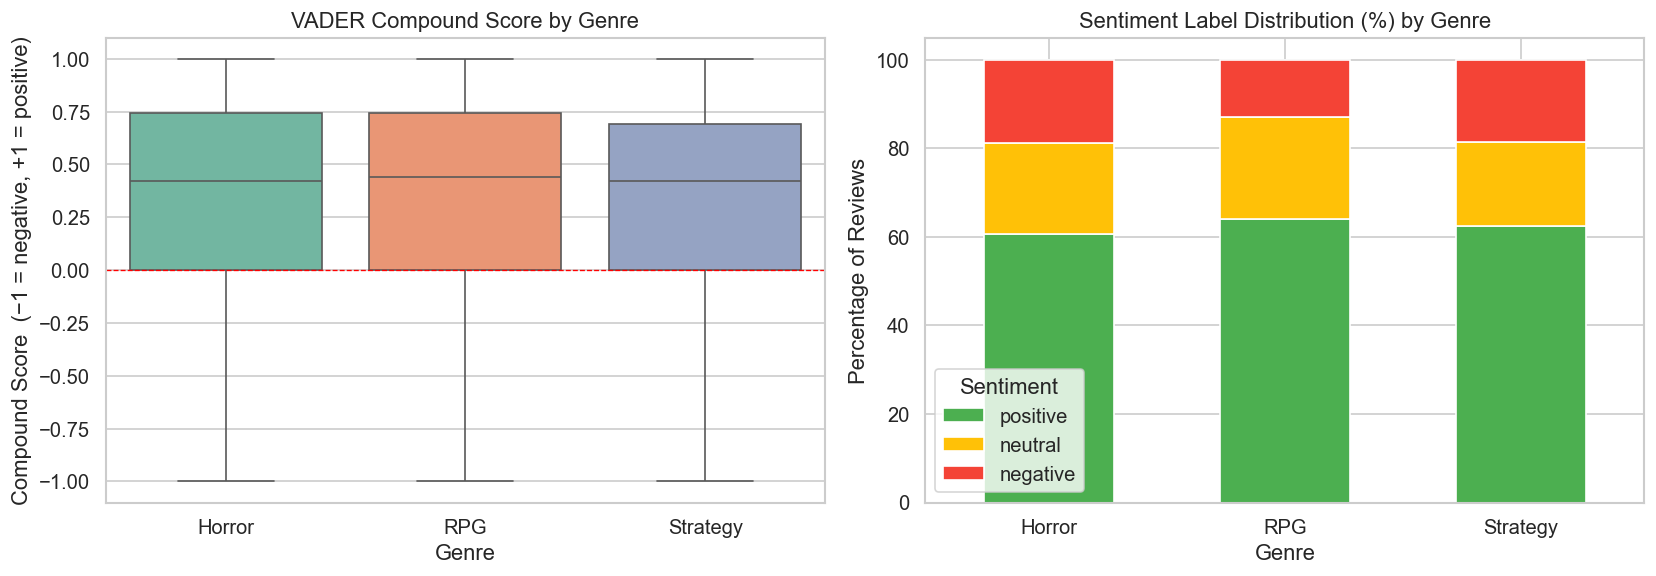

In [5]:
genres  = ['Horror', 'RPG', 'Strategy']
palette = {'positive': '#4CAF50', 'neutral': '#FFC107', 'negative': '#F44336'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: compound score per genre
sns.boxplot(
    data=df, x='Genre', y='vader_compound',
    order=genres, palette='Set2', ax=axes[0]
)
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0].set_title('VADER Compound Score by Genre')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Compound Score  (−1 = negative, +1 = positive)')

# Stacked bar: proportion of positive / neutral / negative
label_counts = (
    df.groupby(['Genre', 'vader_label'])
      .size()
      .unstack(fill_value=0)
      .reindex(index=genres, columns=['positive', 'neutral', 'negative'], fill_value=0)
)
label_pct = label_counts.div(label_counts.sum(axis=1), axis=0) * 100
label_pct.plot(
    kind='bar', stacked=True,
    color=[palette[c] for c in label_pct.columns],
    ax=axes[1], width=0.55
)
axes[1].set_title('Sentiment Label Distribution (%) by Genre')
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Percentage of Reviews')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Sentiment')

plt.tight_layout()
plt.savefig('fig_sentiment_by_genre.png', bbox_inches='tight')
plt.show()

### 3.2 – Per-game sentiment (violin plot)

C:\Users\adity\AppData\Local\Temp\ipykernel_70712\3391373641.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\adity\AppData\Local\Temp\ipykernel_70712\3391373641.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\adity\AppData\Local\Temp\ipykernel_70712\3391373641.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


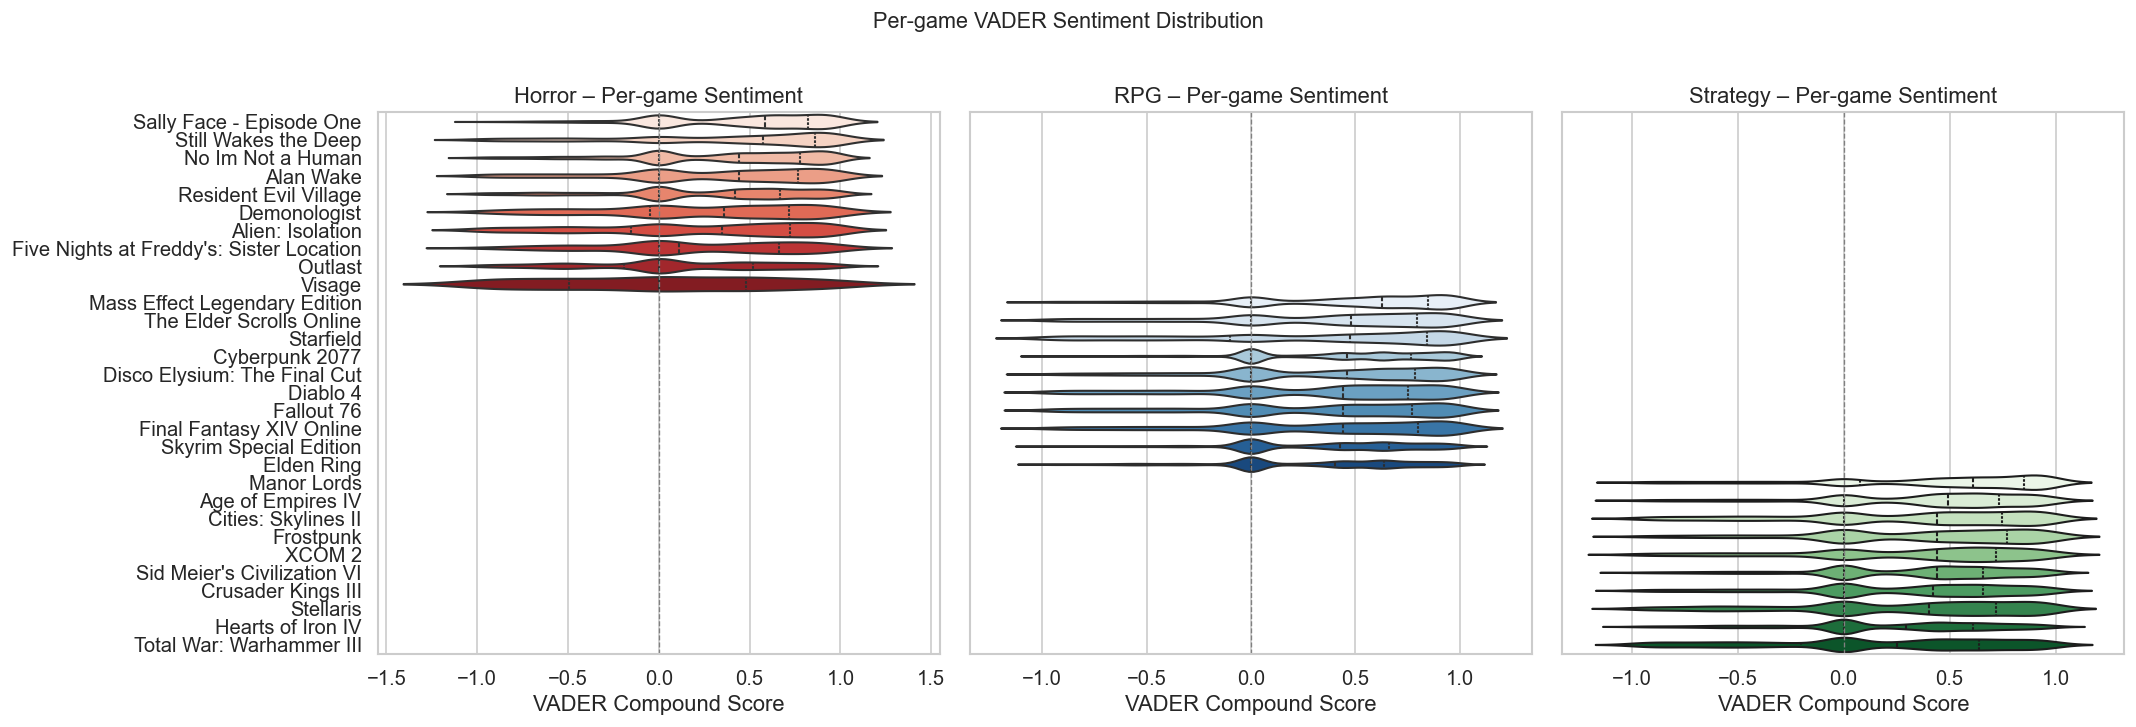

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
genre_palette = {'Horror': 'Reds', 'RPG': 'Blues', 'Strategy': 'Greens'}

for ax, genre in zip(axes, genres):
    subset = df[df['Genre'] == genre].copy()
    order  = (subset.groupby('Game_name')['vader_compound']
                    .median().sort_values(ascending=False).index.tolist())
    sns.violinplot(
        data=subset, y='Game_name', x='vader_compound',
        order=order, orient='h', inner='quartile',
        palette=genre_palette[genre], ax=ax
    )
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(f'{genre} – Per-game Sentiment')
    ax.set_xlabel('VADER Compound Score')
    ax.set_ylabel('')

plt.suptitle('Per-game VADER Sentiment Distribution', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_pergame_sentiment.png', bbox_inches='tight')
plt.show()

### 3.3 – Temporal sentiment trend by genre

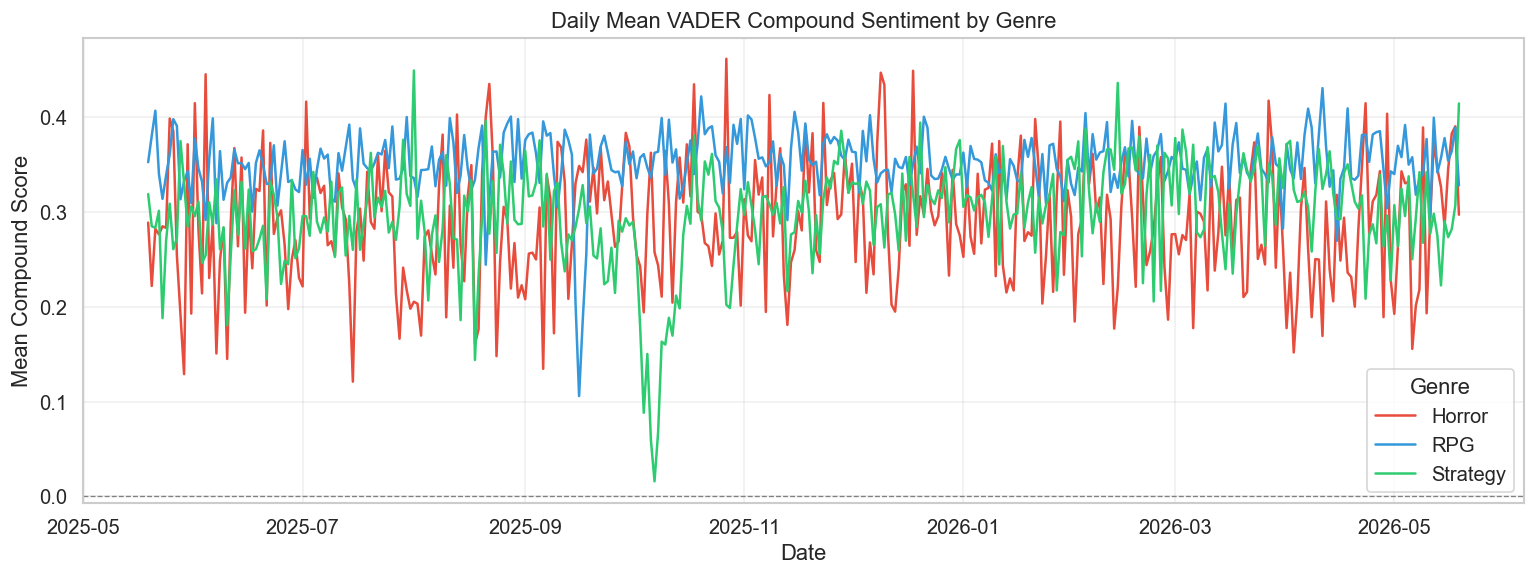

In [7]:
daily = (
    df.groupby(['Genre', 'date'])['vader_compound']
      .mean()
      .reset_index()
)

plt.figure(figsize=(13, 5))
colors = {'Horror': '#E74C3C', 'RPG': '#3498DB', 'Strategy': '#2ECC71'}

for genre in genres:
    g = daily[daily['Genre'] == genre].copy()
    g['date'] = pd.to_datetime(g['date'])
    g = g.sort_values('date')
    plt.plot(g['date'], g['vader_compound'],
             label=genre, color=colors[genre], linewidth=1.5)

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Daily Mean VADER Compound Sentiment by Genre')
plt.xlabel('Date')
plt.ylabel('Mean Compound Score')
plt.legend(title='Genre')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_temporal_sentiment.png', bbox_inches='tight')
plt.show()

### 3.4 – VADER vs. Steam thumbs-up agreement

Overall VADER ↔ Steam thumbs agreement: 64.6%
Genre
Horror      62.2
RPG         65.2
Strategy    64.5
dtype: float64


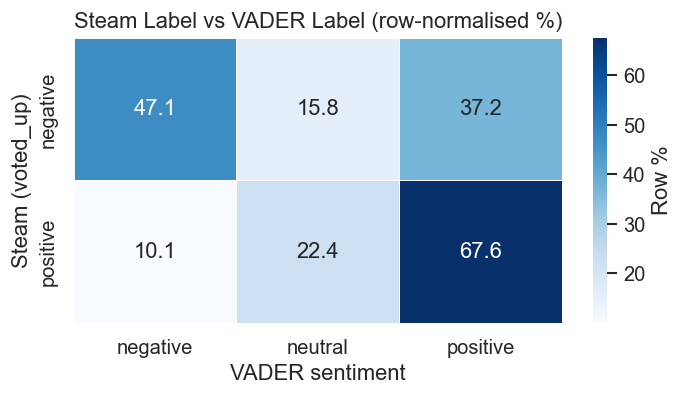

In [8]:
agree_df = df.dropna(subset=['voted_up']).copy()
agree_df['steam_label'] = agree_df['voted_up'].map({True: 'positive', False: 'negative'})

match = (agree_df['vader_label'] == agree_df['steam_label'])
print(f'Overall VADER ↔ Steam thumbs agreement: {match.mean()*100:.1f}%')
print(agree_df.groupby('Genre').apply(lambda x: (x['vader_label'] == x['steam_label']).mean() * 100).round(1))

ct = pd.crosstab(agree_df['steam_label'], agree_df['vader_label'],
                 normalize='index') * 100

plt.figure(figsize=(6, 3.5))
sns.heatmap(ct, annot=True, fmt='.1f', cmap='Blues', linewidths=0.5,
            cbar_kws={'label': 'Row %'})
plt.title('Steam Label vs VADER Label (row-normalised %)')
plt.ylabel('Steam (voted_up)')
plt.xlabel('VADER sentiment')
plt.tight_layout()
plt.savefig('fig_vader_vs_steam.png', bbox_inches='tight')
plt.show()

---
## 4 – Topic Modelling (LDA)

Identifies dominant discussion themes in reviews per genre.

In [9]:
N_TOPICS   = 5
N_TOPWORDS = 8

def run_lda(texts, genre_name):
    texts = texts.dropna()
    texts = texts[texts.str.strip() != '']
    if len(texts) < 20:
        print(f'  [{genre_name}] Too few reviews for LDA – skipping.')
        return

    vect = TfidfVectorizer(
        max_df=0.90, min_df=5,
        max_features=2000,
        stop_words='english',
        token_pattern=r'[a-zA-Z]{3,}'
    )
    try:
        dtm = vect.fit_transform(texts)
    except ValueError as e:
        print(f'  [{genre_name}] Vectoriser error: {e}')
        return

    lda = LatentDirichletAllocation(
        n_components=N_TOPICS, random_state=42,
        max_iter=15, learning_method='online'
    )
    lda.fit(dtm)

    feature_names = vect.get_feature_names_out()
    print(f'\n── {genre_name} Topics ──────────────────────────')
    for i, topic in enumerate(lda.components_):
        top = [feature_names[j] for j in topic.argsort()[-N_TOPWORDS:][::-1]]
        print(f'  Topic {i+1}: {" | ".join(top)}')


for genre in genres:
    run_lda(df[df['Genre'] == genre]['Clean_LDA'], genre)


── Horror Topics ──────────────────────────
  Topic 1: good | game | great | scary | amazing | yes | cool | story
  Topic 2: game | best | horror | games | played | play | story | evil
  Topic 3: peak | game | like | really | awesome | human | story | endings
  Topic 4: beautiful | bad | big | storyline | goat | let | wow | hell
  Topic 5: love | fun | nice | game | ethan | like | absolute | guy

── RPG Topics ──────────────────────────
  Topic 1: yes | nice | masterpiece | like | elden | ring | dont | goat
  Topic 2: game | life | hard | bad | souls | need | diablo | play
  Topic 3: good | game | great | awesome | play | story | really | favorite
  Topic 4: best | fun | game | love | amazing | played | games | time
  Topic 5: game | peak | like | skyrim | story | play | games | world

── Strategy Topics ──────────────────────────
  Topic 1: great | game | love | amazing | yes | gud | super | crashing
  Topic 2: play | dont | fun | pretty | hard | game | awesome | learn
  Topic 3: goo

---
## 5 – Network Analysis

### 5.1 – Build the bipartite user–game graph

In [10]:
B = nx.Graph()

# User nodes
users = df['steamid'].dropna().unique()
B.add_nodes_from(users, bipartite='user')

# Game nodes – prefix 'g_' to avoid any collision with steamids
game_node = {aid: f'g_{aid}' for aid in df['appid'].unique()}
for aid, gn in game_node.items():
    row = appid_dict.get(aid, [aid, 'Unknown'])
    B.add_node(gn, bipartite='game', appid=aid,
               Game_name=row[0], Genre=row[1])

# Edges: user reviewed game
edge_counts = (
    df.dropna(subset=['steamid'])
      .groupby(['steamid', 'appid'])
      .size()
      .reset_index(name='n_reviews')
)
for _, row in edge_counts.iterrows():
    B.add_edge(row['steamid'], game_node[row['appid']],
               weight=int(row['n_reviews']))

user_nodes = {n for n, d in B.nodes(data=True) if d.get('bipartite') == 'user'}
game_nodes = {n for n, d in B.nodes(data=True) if d.get('bipartite') == 'game'}

print(f'Bipartite graph')
print(f'  User nodes : {len(user_nodes):,}')
print(f'  Game nodes : {len(game_nodes):,}')
print(f'  Edges      : {B.number_of_edges():,}')
print(f'  Is bipartite: {bipartite.is_bipartite(B)}')

Bipartite graph
  User nodes : 207,832
  Game nodes : 30
  Edges      : 218,593
  Is bipartite: True


### 5.2 – Cross-genre reviewer behaviour

Cross-genre reviewer distribution:
  1 genre: 203,528 users (97.9%)
  2 genres: 4,196 users (2.0%)
  3 genres: 108 users (0.1%)


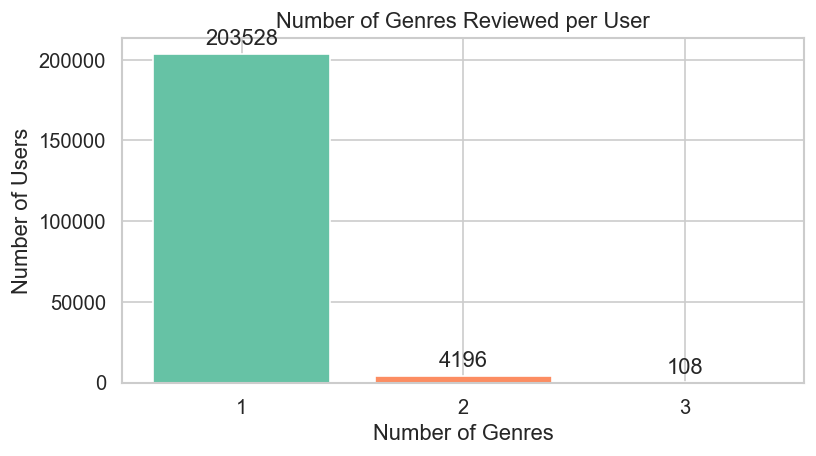

In [11]:
user_genre_map = (
    df.dropna(subset=['steamid'])
      .groupby('steamid')['Genre']
      .apply(set)
)

user_genres = user_genre_map.apply(len).reset_index()
user_genres.columns = ['steamid', 'n_genres']

dist = user_genres['n_genres'].value_counts().sort_index()
total = len(user_genres)

print('Cross-genre reviewer distribution:')
for n, cnt in dist.items():
    g = 'genre' if n == 1 else 'genres'
    print(f'  {n} {g}: {cnt:,} users ({cnt/total*100:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    dist.index.astype(str), dist.values,
    color=sns.color_palette('Set2', len(dist)), edgecolor='white'
)
ax.bar_label(bars, fmt='%d', padding=3)
ax.set_title('Number of Genres Reviewed per User')
ax.set_xlabel('Number of Genres')
ax.set_ylabel('Number of Users')
plt.tight_layout()
plt.savefig('fig_cross_genre_users.png', bbox_inches='tight')
plt.show()

### 5.3 – Genre co-occurrence graph

Two genres are connected when at least one user reviewed both. Edge weight = number of shared reviewers.

Genre co-occurrence edges:
  Horror ↔ RPG:  1,833 shared reviewers
  Horror ↔ Strategy:  425 shared reviewers
  RPG ↔ Strategy:  2,262 shared reviewers


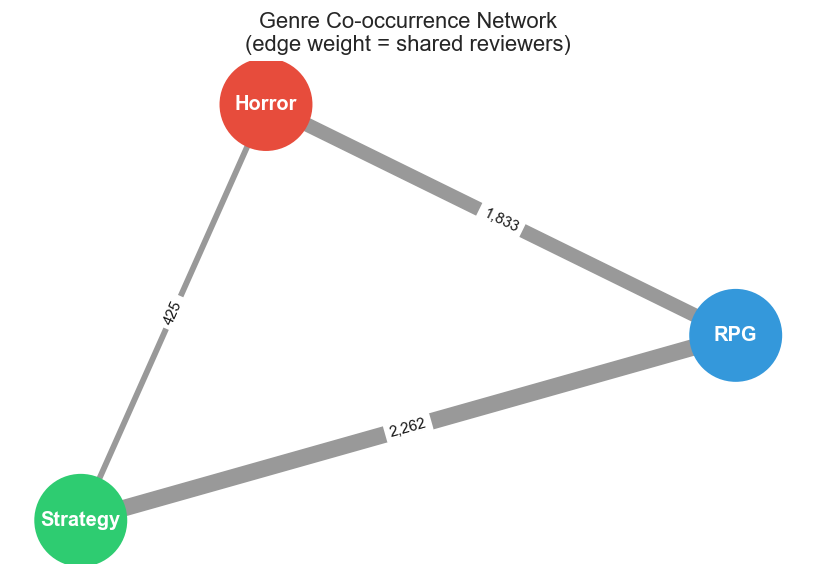

In [12]:
genre_graph = nx.Graph()
genre_graph.add_nodes_from(genres)

for uid, genre_set in user_genre_map.items():
    for g1, g2 in combinations(sorted(genre_set), 2):
        if genre_graph.has_edge(g1, g2):
            genre_graph[g1][g2]['weight'] += 1
        else:
            genre_graph.add_edge(g1, g2, weight=1)

print('Genre co-occurrence edges:')
for u, v, d in genre_graph.edges(data=True):
    print(f'  {u} ↔ {v}:  {d["weight"]:,} shared reviewers')

# Visualise
fig, ax = plt.subplots(figsize=(7, 5))
pos     = nx.spring_layout(genre_graph, seed=42, k=2)
weights = [genre_graph[u][v]['weight'] for u, v in genre_graph.edges()]
max_w   = max(weights) if weights else 1
widths  = [2 + 8 * (w / max_w) for w in weights]

nx.draw_networkx_nodes(
    genre_graph, pos, node_size=3000,
    node_color=['#E74C3C', '#3498DB', '#2ECC71'], ax=ax
)
nx.draw_networkx_labels(genre_graph, pos, font_size=12, font_weight='bold',
                        font_color='white', ax=ax)
nx.draw_networkx_edges(genre_graph, pos, width=widths,
                       edge_color='#555555', alpha=0.6, ax=ax)
nx.draw_networkx_edge_labels(
    genre_graph, pos,
    edge_labels={(u, v): f"{d['weight']:,}" for u, v, d in genre_graph.edges(data=True)},
    font_size=9, ax=ax
)
ax.set_title('Genre Co-occurrence Network\n(edge weight = shared reviewers)')
ax.axis('off')
plt.tight_layout()
plt.savefig('fig_genre_cooccurrence.png', bbox_inches='tight')
plt.show()

### 5.4 – SNA measures on the genre co-occurrence graph

In [13]:
if genre_graph.number_of_edges() > 0:
    sna = pd.DataFrame({
        'Degree Centrality'      : nx.degree_centrality(genre_graph),
        'Betweenness Centrality' : nx.betweenness_centrality(genre_graph, weight='weight'),
        'Closeness Centrality'   : nx.closeness_centrality(genre_graph),
    }).round(4)

    print(sna.to_string())
    print(f'\nTransitivity (global clustering): {nx.transitivity(genre_graph):.4f}')
    print(f'Graph density:                    {nx.density(genre_graph):.4f}')
else:
    print('No cross-genre reviewers found – co-occurrence graph is empty.')

          Degree Centrality  Betweenness Centrality  Closeness Centrality
Horror                  1.0                     1.0                   1.0
RPG                     1.0                     0.0                   1.0
Strategy                1.0                     0.0                   1.0

Transitivity (global clustering): 1.0000
Graph density:                    1.0000


### 5.5 – Bipartite graph visualisation (top reviewers)

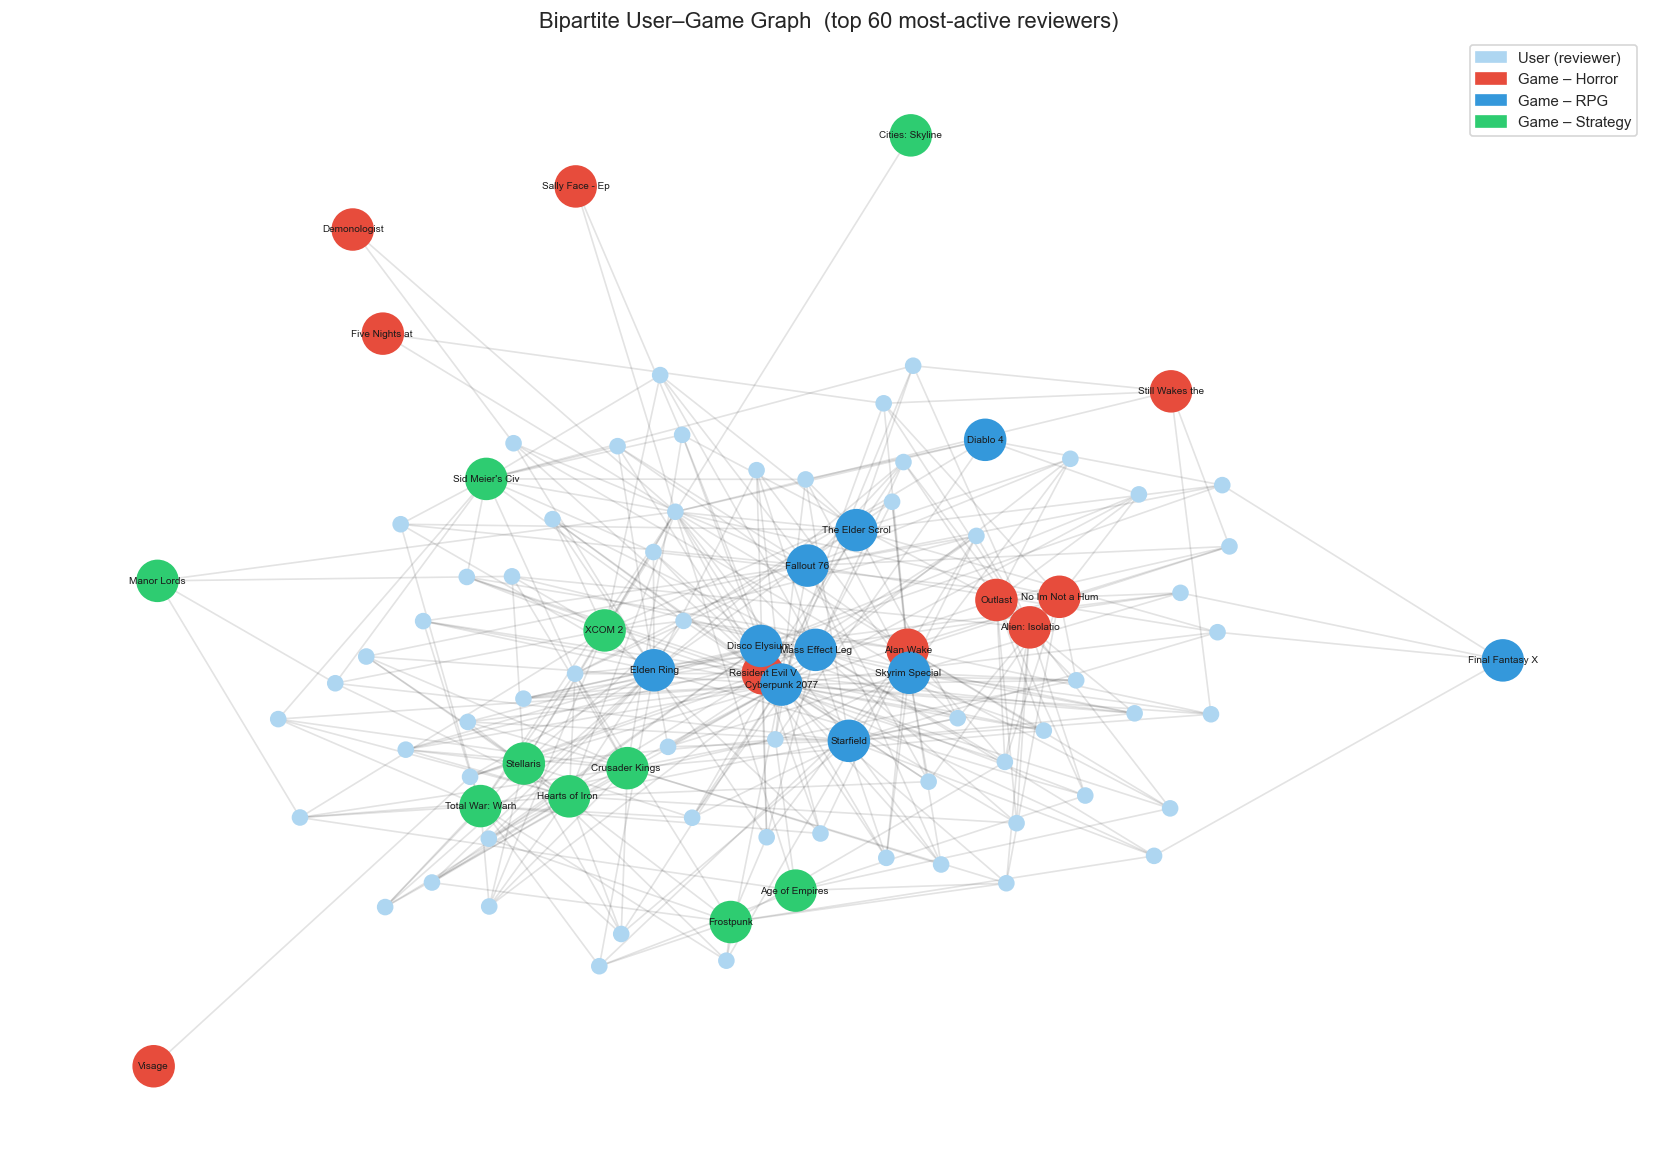

In [14]:
TOP_N = 60   # most-active reviewers to include

top_users = (
    df.dropna(subset=['steamid'])
      .groupby('steamid')['appid']
      .nunique()
      .nlargest(TOP_N)
      .index.tolist()
)

sub_nodes = set(top_users)
for u in top_users:
    if u in B:
        sub_nodes.update(B.neighbors(u))

sub_B = B.subgraph(sub_nodes).copy()

genre_colors = {'Horror': '#E74C3C', 'RPG': '#3498DB', 'Strategy': '#2ECC71'}

node_colors, node_sizes = [], []
for n, d in sub_B.nodes(data=True):
    if d.get('bipartite') == 'user':
        node_colors.append('#AED6F1')
        node_sizes.append(80)
    else:
        node_colors.append(genre_colors.get(d.get('Genre', ''), '#AAAAAA'))
        node_sizes.append(600)

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(sub_B, seed=42, k=0.5)

nx.draw_networkx_nodes(sub_B, pos, node_color=node_colors,
                       node_size=node_sizes, ax=ax)
nx.draw_networkx_edges(sub_B, pos, alpha=0.12, ax=ax)

game_labels = {
    n: d.get('Game_name', n)[:15]
    for n, d in sub_B.nodes(data=True)
    if d.get('bipartite') == 'game'
}
nx.draw_networkx_labels(sub_B, pos, labels=game_labels, font_size=6, ax=ax)

legend_handles = [mpatches.Patch(color='#AED6F1', label='User (reviewer)')]
for g, c in genre_colors.items():
    legend_handles.append(mpatches.Patch(color=c, label=f'Game – {g}'))
ax.legend(handles=legend_handles, loc='upper right', fontsize=9)
ax.set_title(f'Bipartite User–Game Graph  (top {TOP_N} most-active reviewers)')
ax.axis('off')
plt.tight_layout()
plt.savefig('fig_bipartite_graph.png', bbox_inches='tight')
plt.show()

### 5.6 – User degree distribution

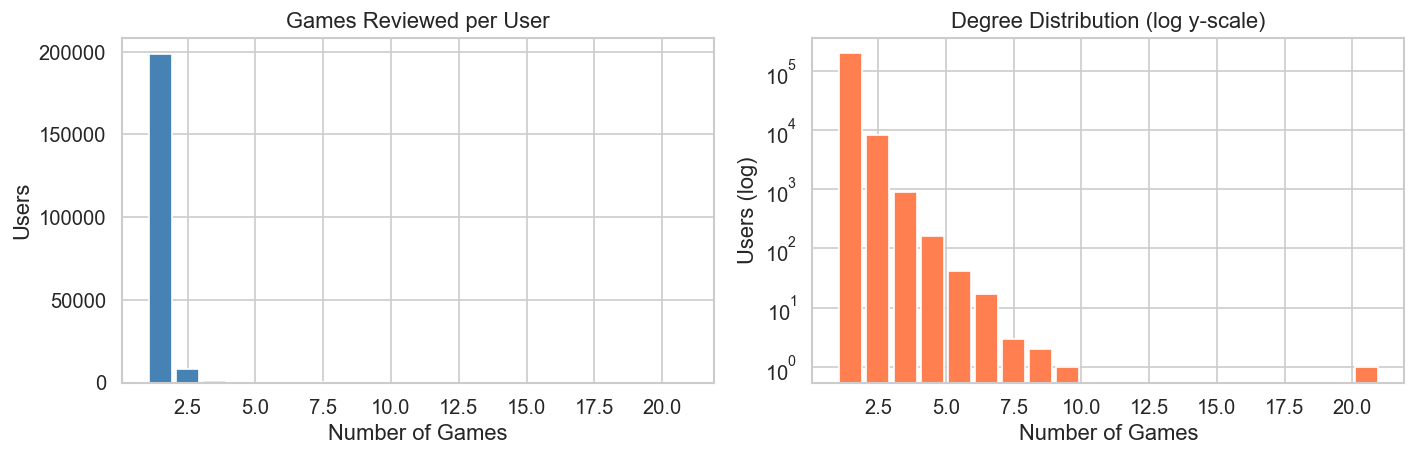

count    207832.000000
mean          1.051777
std           0.262784
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          20.000000
Name: games_reviewed, dtype: float64


In [15]:
user_degree = pd.Series(
    {n: B.degree(n) for n in user_nodes},
    name='games_reviewed'
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

max_bin = min(int(user_degree.max()) + 2, 25)
axes[0].hist(user_degree, bins=range(1, max_bin),
             color='steelblue', edgecolor='white', rwidth=0.85)
axes[0].set_title('Games Reviewed per User')
axes[0].set_xlabel('Number of Games')
axes[0].set_ylabel('Users')

axes[1].hist(user_degree, bins=range(1, max_bin),
             color='coral', edgecolor='white', rwidth=0.85, log=True)
axes[1].set_title('Degree Distribution (log y-scale)')
axes[1].set_xlabel('Number of Games')
axes[1].set_ylabel('Users (log)')

plt.tight_layout()
plt.savefig('fig_degree_distribution.png', bbox_inches='tight')
plt.show()

print(user_degree.describe())

---
## 6 – Community Detection

Project the bipartite graph onto games (games share an edge if they share reviewers), then detect communities.

In [16]:
game_proj = bipartite.weighted_projected_graph(B, game_nodes)
print(f'Game projection: {game_proj.number_of_nodes()} nodes, {game_proj.number_of_edges()} edges')

communities = list(greedy_modularity_communities(game_proj, weight='weight'))
node_community = {n: i for i, comm in enumerate(communities) for n in comm}

print(f'Communities detected: {len(communities)}')
for i, comm in enumerate(communities):
    genre_breakdown = Counter(B.nodes[n].get('Genre', '?') for n in comm)
    names = [B.nodes[n].get('Game_name', n) for n in comm]
    print(f'  Community {i}: {dict(genre_breakdown)} → {names}')

Game projection: 30 nodes, 413 edges
Communities detected: 3
  Community 0: {'RPG': 5, 'Horror': 10} → ['Disco Elysium: The Final Cut', 'Demonologist', 'Cyberpunk 2077', 'Elden Ring', 'Outlast', 'No Im Not a Human', "Five Nights at Freddy's: Sister Location", 'Visage', 'Still Wakes the Deep', 'Alien: Isolation', 'Alan Wake', 'Sally Face - Episode One', 'Resident Evil Village', 'Mass Effect Legendary Edition', 'Skyrim Special Edition']
  Community 1: {'Strategy': 10} → ["Sid Meier's Civilization VI", 'Stellaris', 'Hearts of Iron IV', 'XCOM 2', 'Crusader Kings III', 'Frostpunk', 'Cities: Skylines II', 'Total War: Warhammer III', 'Age of Empires IV', 'Manor Lords']
  Community 2: {'RPG': 5} → ['Starfield', 'The Elder Scrolls Online', 'Diablo 4', 'Final Fantasy XIV Online', 'Fallout 76']


C:\Users\adity\AppData\Local\Temp\ipykernel_70712\500778164.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1', max(len(communities), 2))


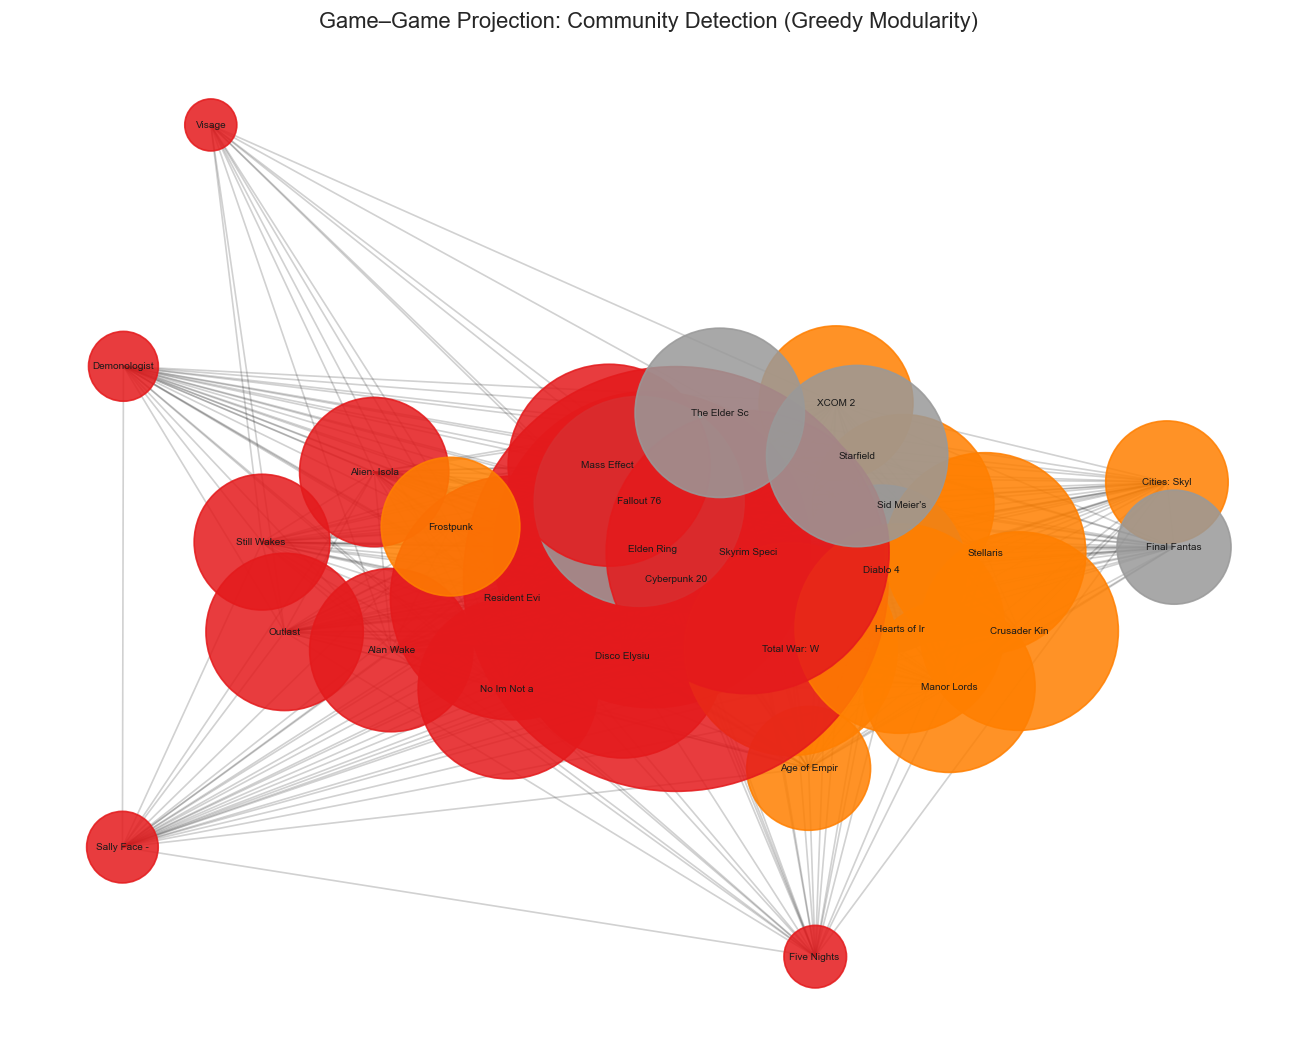

In [17]:
fig, ax = plt.subplots(figsize=(11, 9))
pos = nx.spring_layout(game_proj, seed=42, k=1.8)
cmap = plt.cm.get_cmap('Set1', max(len(communities), 2))

nc = [cmap(node_community.get(n, 0)) for n in game_proj.nodes()]
ns = [300 + 15 * game_proj.degree(n, weight='weight') for n in game_proj.nodes()]

nx.draw_networkx_nodes(game_proj, pos, node_color=nc, node_size=ns, ax=ax, alpha=0.85)
nx.draw_networkx_edges(game_proj, pos, alpha=0.2, ax=ax)
nx.draw_networkx_labels(
    game_proj, pos,
    labels={n: B.nodes[n].get('Game_name', n)[:12] for n in game_proj.nodes()},
    font_size=6, ax=ax
)
ax.set_title('Game–Game Projection: Community Detection (Greedy Modularity)')
ax.axis('off')
plt.tight_layout()
plt.savefig('fig_community_detection.png', bbox_inches='tight')
plt.show()

---
## 7 – Summary & Export

In [18]:
summary = df.groupby('Genre').agg(
    n_reviews       = ('review',        'count'),
    n_unique_users  = ('steamid',       'nunique'),
    mean_compound   = ('vader_compound', 'mean'),
    median_compound = ('vader_compound', 'median'),
    pct_positive    = ('vader_label',   lambda x: (x == 'positive').mean() * 100),
    pct_neutral     = ('vader_label',   lambda x: (x == 'neutral').mean()  * 100),
    pct_negative    = ('vader_label',   lambda x: (x == 'negative').mean() * 100),
).reindex(genres).round(3)

print(summary.to_string())

# Save outputs
df.to_csv('steam_reviews_with_sentiment.csv', index=False)
summary.to_csv('sentiment_summary_by_genre.csv')
nx.write_graphml(B,           'bipartite_user_game.graphml')
nx.write_graphml(genre_graph, 'genre_cooccurrence.graphml')
nx.write_graphml(game_proj,   'game_projection.graphml')

print('\nAll files saved.')

          n_reviews  n_unique_users  mean_compound  median_compound  pct_positive  pct_neutral  pct_negative
Genre                                                                                                       
Horror        29529           28775          0.293            0.422        60.737       20.438        18.826
RPG          125866          121893          0.351            0.440        64.108       22.924        12.968
Strategy      63198           61576          0.289            0.422        62.516       18.920        18.564

All files saved.
